In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("ships.csv", encoding="latin1")
df = df.rename(columns={"DWT DATE": "DWT"})

# derived column needed for the L_bp x T/D plot (T = draft d, D = depth)
df["T/D"] = df["Draft (d)"] / df["Depth (D)"]

df.head()


,SHIP'S NAME,COUNTRY,DWT,L_BP,Beam (B),Depth (D),Draft (d),SPEED (m/s),L/B,L/D,B/D,B/d,L/d,D/d,Fr,T/D
0,FLYING OFFICER NIRMAL JIT SINGH SEKHON PVC,INDIA,40700,184.0,30.4,17.80,12.4,7.20160,6.052632,10.337079,1.707865,2.451613,14.838710,1.435484,0.169506,0.696629
1,PEACEVENTURE L,GREECE,38500,169.0,32.2,17.45,11.7,7.45880,5.248447,9.684814,1.845272,2.752137,14.444444,1.491453,0.183186,0.670487
2,PRIDEVENTURE L,GREECE,38500,169.0,32.2,17.45,11.7,7.20160,5.248447,9.684814,1.845272,2.752137,14.444444,1.491453,0.176869,0.670487
3,POWERVENTURE L,GREECE,38500,169.0,32.2,17.45,11.7,7.66456,5.248447,9.684814,1.845272,2.752137,14.444444,1.491453,0.188239,0.670487
4,FRATERNITY L,GREECE,38500,169.0,32.2,17.45,11.7,7.51024,5.248447,9.684814,1.845272,2.752137,14.444444,1.491453,0.184449,0.670487


## Dispersion plots (x, y)

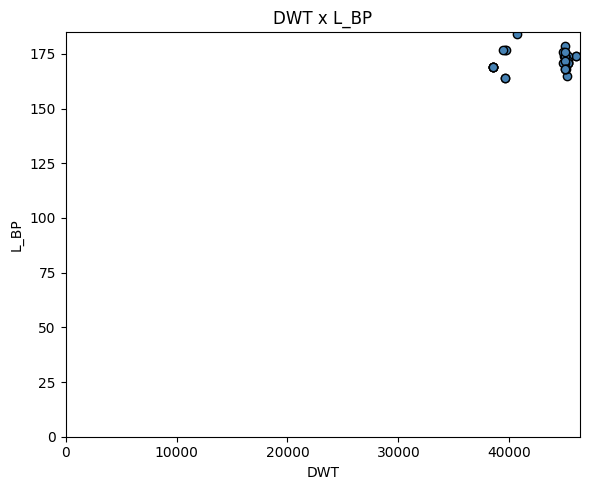

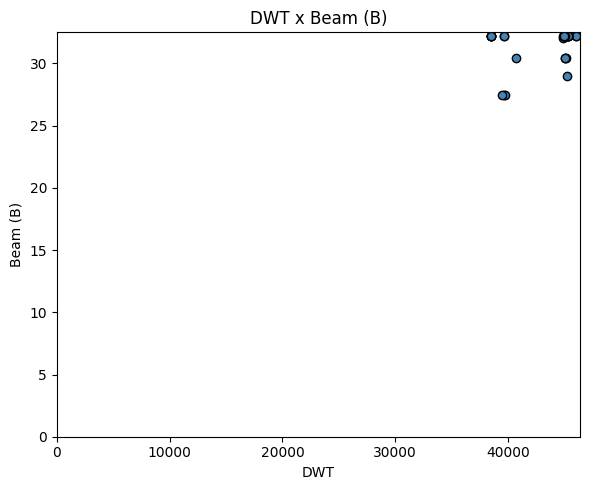

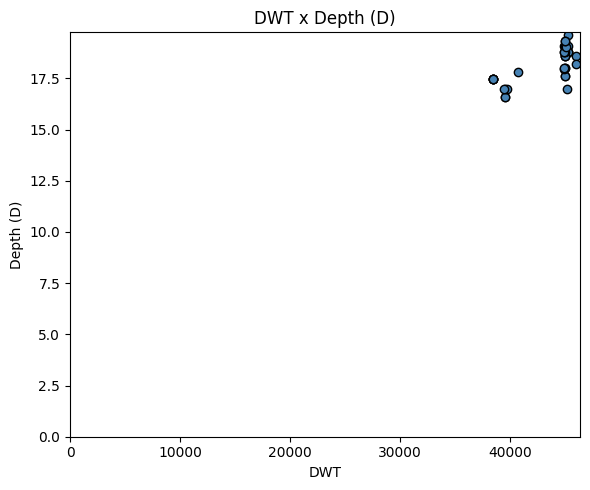

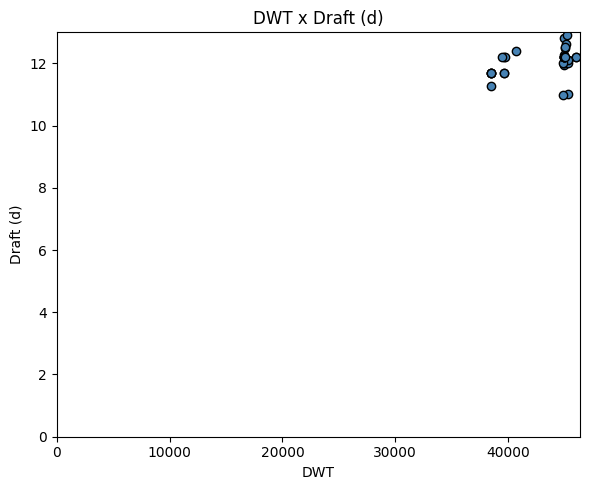

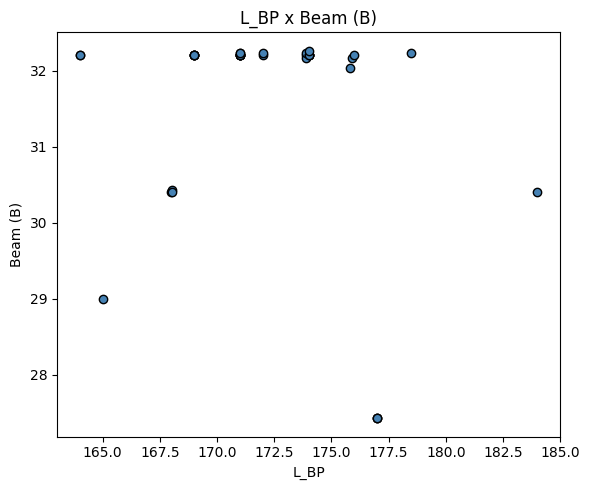

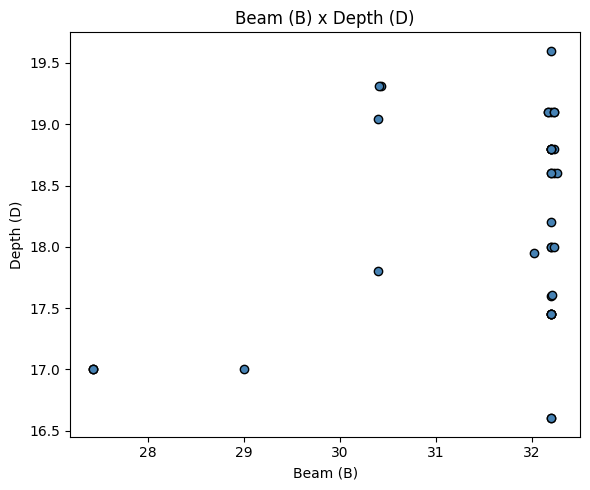

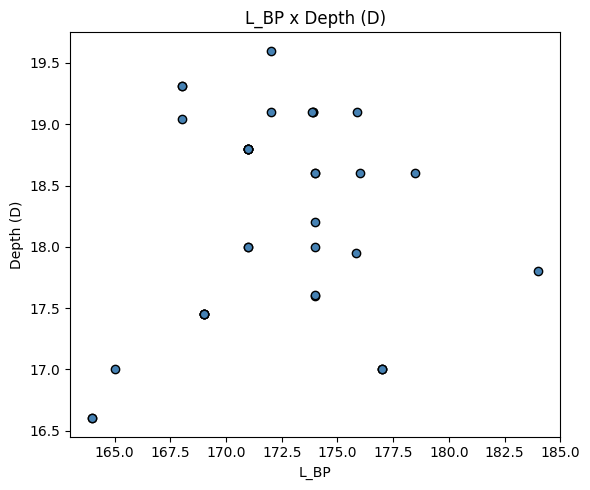

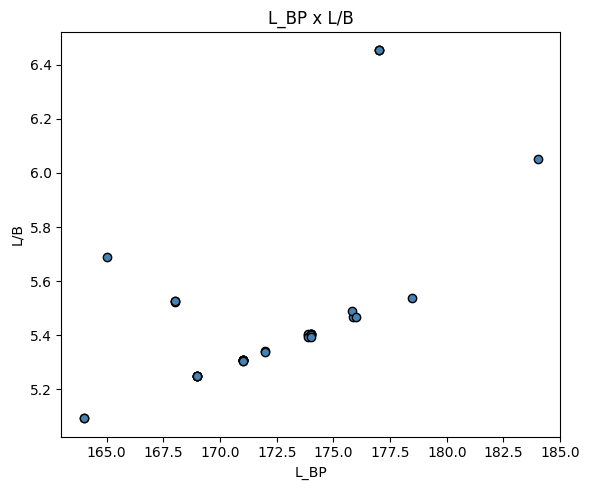

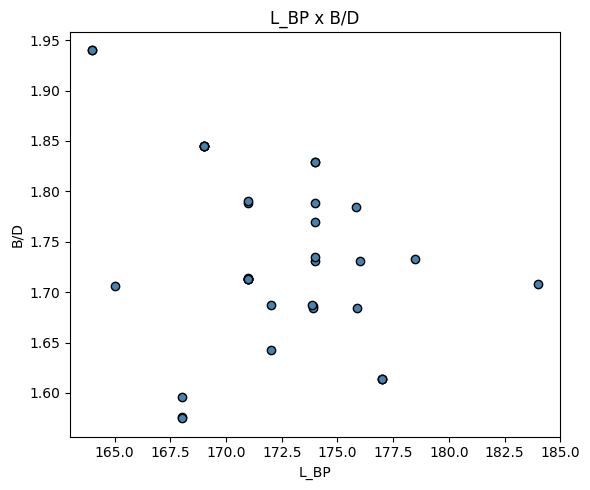

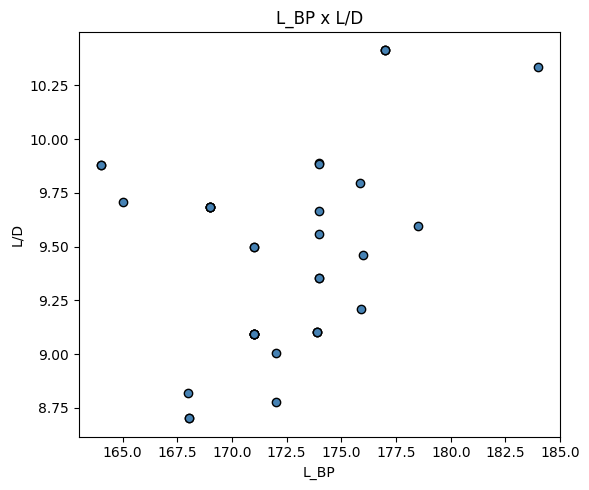

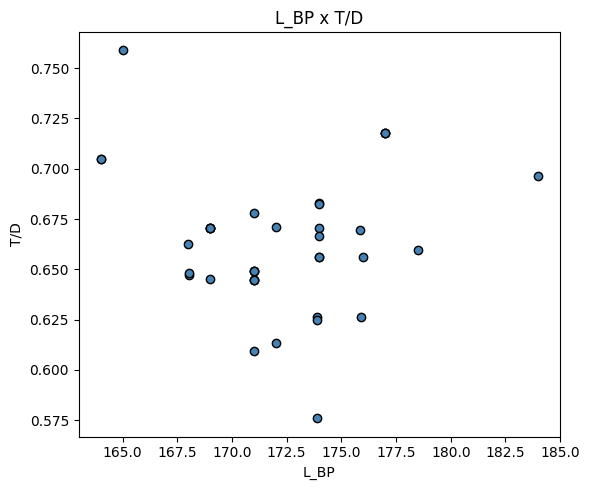

In [5]:
SCATTER_PAIRS = [
    ("DWT", "L_BP"),
    ("DWT", "Beam (B)"),
    ("DWT", "Depth (D)"),
    ("DWT", "Draft (d)"),
    ("L_BP", "Beam (B)"),
    ("Beam (B)", "Depth (D)"),
    ("L_BP", "Depth (D)"),
    ("L_BP", "L/B"),
    ("L_BP", "B/D"),
    ("L_BP", "L/D"),
    ("L_BP", "T/D"),
]

for x, y in SCATTER_PAIRS:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df[x], df[y], color="steelblue", edgecolor="black")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} x {y}")
    if x == "DWT":
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


## Análise estatística descritiva

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()


def mode_of(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan


stats_rows = {}
for col in numeric_cols:
    s = df[col].dropna()
    mean = s.mean()
    std = s.std(ddof=1)
    stats_rows[col] = {
        "media": mean,
        "mediana": s.median(),
        "max": s.max(),
        "min": s.min(),
        "moda": mode_of(s),
        "faixa": s.max() - s.min(),
        "erro padrao": stats.sem(s),
        "variancia": s.var(ddof=1),
        "desv pad": std,
        "coef variancia": std / mean if mean != 0 else np.nan,
        "skewness": stats.skew(s),
        "kurtosis": stats.kurtosis(s),
    }

stats_df = pd.DataFrame(stats_rows).T
stats_df


,media,mediana,max,min,moda,faixa,erro padrao,variancia,desv pad,coef variancia,skewness,kurtosis
DWT,43409.157895,44990.000000,46000.000000,38500.000000,38500.000000,7500.000000,447.887014,7.622906e+06,2760.960982,0.063603,-0.963200,-0.947571
L_BP,172.129552,171.500000,184.000000,164.000000,171.000000,20.000000,0.663163,1.671182e+01,4.088010,0.023750,0.273639,0.632600
Beam (B),31.550263,32.200000,32.259998,27.430000,32.200000,4.829998,0.231453,2.035687e+00,1.426775,0.045222,-2.113239,3.156348
Depth (D),18.199184,18.400000,19.600000,16.600000,18.799999,3.000000,0.137896,7.225820e-01,0.850048,0.046708,-0.285423,-1.150074
Draft (d),12.051658,12.116000,12.900000,10.970000,11.700000,1.929999,0.066182,1.664432e-01,0.407975,0.033852,-0.671412,1.161916
SPEED (m/s),7.515655,7.458800,7.973200,7.098720,7.458800,0.874480,0.040314,6.175927e-02,0.248514,0.033066,0.109611,-0.997269
L/B,5.469194,5.397977,6.452789,5.093168,5.310559,1.359621,0.054080,1.111366e-01,0.333372,0.060954,2.117909,3.706166
L/D,9.476923,9.500000,10.411765,8.701709,9.095745,1.710056,0.076292,2.211770e-01,0.470295,0.049625,0.336626,-0.526637
B/D,1.735993,1.713537,1.939759,1.574832,1.712766,0.364927,0.014959,8.503090e-03,0.092212,0.053118,0.265271,-0.372184
B/d,2.622389,2.657643,2.938013,2.248062,2.752137,0.689951,0.028032,2.985943e-02,0.172799,0.065894,-0.800179,0.349137
